In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 2 plot

In [2]:
# Constants
omega_e = 2*np.pi/86164.1
omega_s = 2*np.pi/6745.72
i = 66.04*np.pi/180

# Time array: 10 days
t_end = 10*24*3600
dt = 60
t = np.arange(0, t_end, dt)

# Latitude
phi = np.arcsin(np.sin(i)*np.sin(omega_s*t))

# Longitude
lam = np.arctan2(np.cos(i)*np.sin(omega_s*t),
                 np.cos(omega_s*t)) - omega_e*t

# Wrap longitude
lam = (lam + np.pi) % (2*np.pi) - np.pi

# Convert to degrees
lat = np.degrees(phi)
lon = np.degrees(lam)

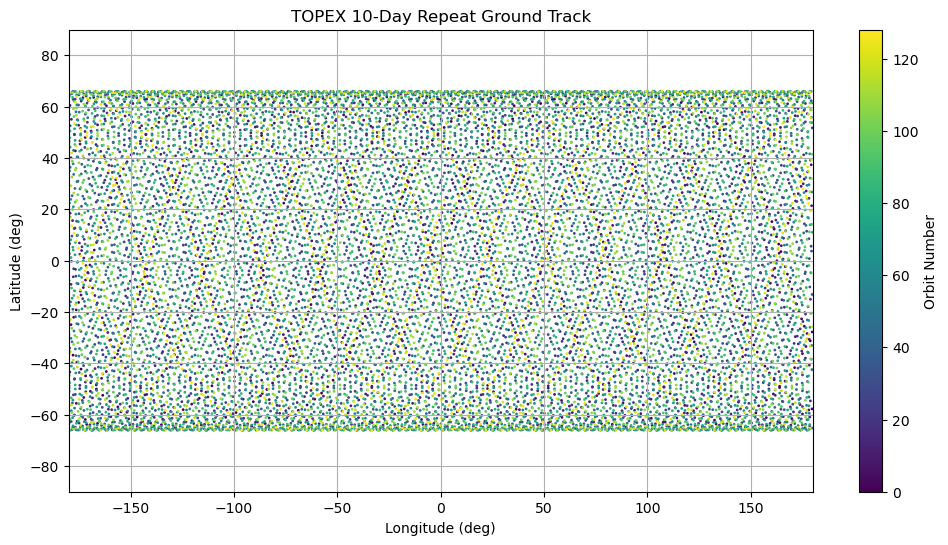

In [3]:
# Orbit number
orbit_period = 6745.72
orbit_number = (t/orbit_period).astype(int)

# Plot
plt.figure(figsize=(12,6))
sc = plt.scatter(lon, lat, c=orbit_number,
                 s=1, cmap='viridis')

plt.colorbar(sc, label='Orbit Number')
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("TOPEX 10-Day Repeat Ground Track")
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.grid(True)
plt.show()

In [4]:
# Landsat parameters
omega_s_ls = 2*np.pi/(99*60)
i_ls = 98.2*np.pi/180

# 3 days of data
t_end_ls = 3*24*3600
t_ls = np.arange(0, t_end_ls, dt)

phi_ls = np.arcsin(np.sin(i_ls)*np.sin(omega_s_ls*t_ls))
lam_ls = np.arctan2(np.cos(i_ls)*np.sin(omega_s_ls*t_ls),
                    np.cos(omega_s_ls*t_ls)) - omega_e*t_ls

lam_ls = (lam_ls + np.pi) % (2*np.pi) - np.pi

lat_ls = np.degrees(phi_ls)
lon_ls = np.degrees(lam_ls)


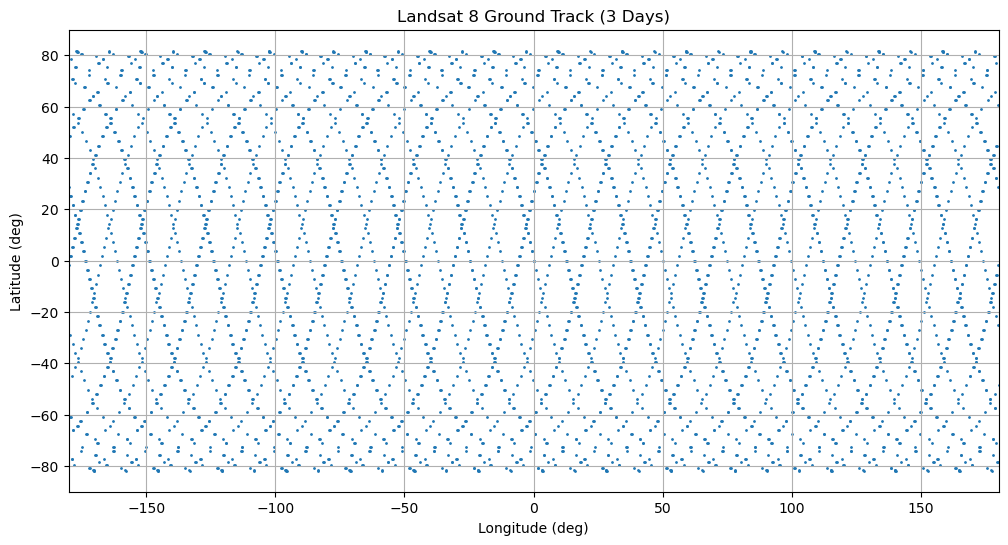

In [5]:
plt.figure(figsize=(12,6))
plt.scatter(lon_ls, lat_ls, s=1)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Landsat 8 Ground Track (3 Days)")
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.grid(True)
plt.show()

## Question 5

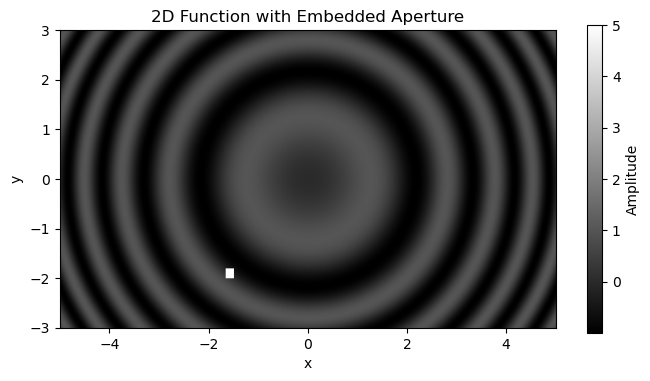

In [6]:
# Create coordinate vectors
x = np.linspace(-5, 5, 600)
y = np.linspace(-3, 3, 300)

# Create 2D grid
X, Y = np.meshgrid(x, y)

# Create an interesting 2D function
Z = np.sin(X**2 + Y**2)

# Modify a small patch (your "aperture")
Z[50:60, 200:210] = 5  # note indexing is [row, column] = [y, x]

# Plot
plt.figure(figsize=(8,4))
plt.imshow(Z, cmap='gray', extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
plt.colorbar(label='Amplitude')
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Function with Embedded Aperture')
plt.show()

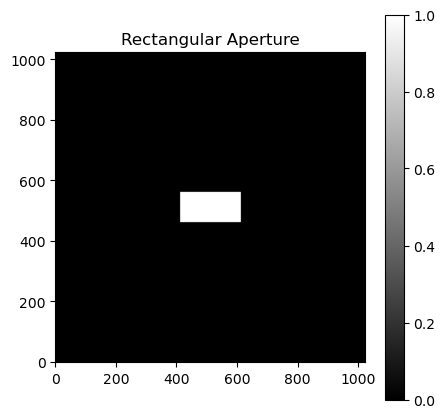

In [7]:
# Create empty array
aperture = np.zeros((1024,1024))

# Insert rectangular aperture
aperture[462:562, 412:612] = 1   # 100 pixels tall, 200 pixels wide

# Plot aperture
plt.figure(figsize=(5,5))
plt.imshow(aperture, cmap='gray', origin='lower')
plt.title("Rectangular Aperture")
plt.colorbar()
plt.show()

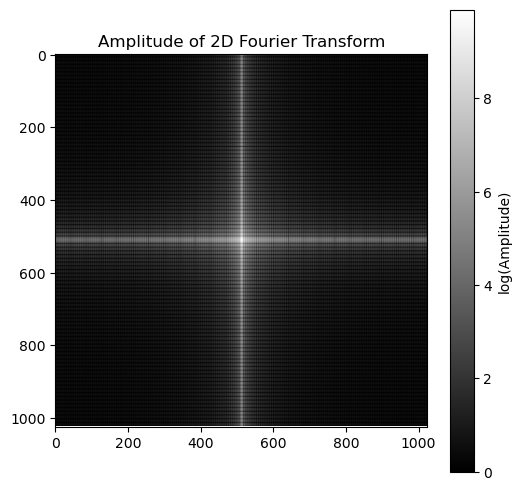

In [8]:
# Compute 2D FFT
fft2 = np.fft.fft2(aperture)

# Shift zero frequency to center
fft2_shifted = np.fft.fftshift(fft2)

# Compute amplitude
amplitude = np.abs(fft2_shifted)

# Plot amplitude (use log scale for visibility)
plt.figure(figsize=(6,6))
plt.imshow(np.log(amplitude + 1), cmap='gray')
plt.title("Amplitude of 2D Fourier Transform")
plt.colorbar(label='log(Amplitude)')
plt.show()